# Build and train MicNet

In [1]:
import matplotlib.pyplot as plt
import os
import math
import numpy as np
import pandas as pd
import re
import sys

import skimage

import time
import torch
import torch.hub
import torch.nn


from MicNet_model import *
from utils_data import Dataset
from utils_data import normalize, augmentor
from utils_eval import NCESoftmaxLoss, NCECriterion


## 1) Load data

In [ ]:
# Load previously generated gene statistics
gene_stat = pd.read_csv("./output/Dataset_MOB/spinal_gene_set_count_stats.csv", index_col=0)

In [ ]:
# Use image 1-4 as training, 5-12 as testing
cols = ["coords"]
cols.extend(gene_stat.columns.values)
image_dict = dict()
count_created = False
for image_id in np.arange(1, 5):
    _image_dict = torch.load("./output/Dataset_MOB/image_HE_Rep{}_MOB_dict.pt".format(image_id))
    _count = pd.read_csv("./output/Dataset_MOB/HE_Rep{}_MOB_count.csv".format(image_id), usecols=cols)
    
    # Update index
    _image_dict = dict(zip(["{}_{}".format(image_id, _) for _ in _image_dict.keys()], _image_dict.values()))
    image_dict.update(_image_dict)
    
    _count.loc[:, "coords"] = ["{}_{}".format(image_id, _) for _ in _count.loc[:, "coords"].values]
    _count = _count.set_index("coords")
    
    if count_created:
        count = pd.concat([count, _count])
    else:
        count = _count
        count_created = True

In [4]:
# Log2
count = np.log2(count + 1)

# Normalize gene_stat by divided with max value
tile_95 = np.log2(gene_stat.loc['max', :].values + 1)
tile_95[tile_95 < 1] = 1
count = count/tile_95

In [5]:
# Get indexes for each image/count point
indexes = list(set(image_dict.keys()) & set(count.index.values))
indexes.sort()
print("# of samples: {}".format(len(indexes)))

# of samples: 1080


## 2) Check data loader

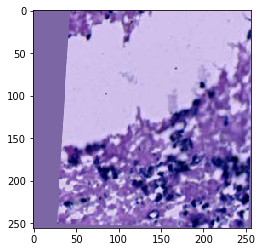

tensor([658])


In [8]:
# Generator
train_set = Dataset(indexes, image_dict, count, augmentation=True)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=1, shuffle=True, num_workers=1)
for x, y in train_loader:
    plt.imshow(normalize(np.transpose(x['image'][0].numpy(), (1, 2, 0)), inverse=True))
    plt.show()
    print(y)
    break

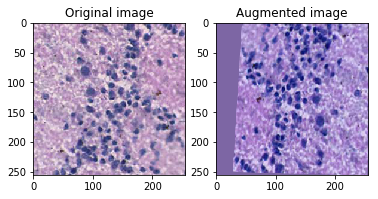

In [9]:
image = image_dict[list(image_dict.keys())[10]]
plt.subplot(121)
plt.imshow(image)
plt.title("Original image")
plt.subplot(122)
plt.imshow(normalize(augmentor(normalize(image)), inverse=True))
plt.title("Augmented image")
plt.show()

## 3) Create network

In [10]:
device = "cuda:0"
image_shape = image_dict[list(image_dict.keys())[0]].shape[0]
n_genes = gene_stat.shape[1]
n_data = len(indexes)
n_out_features = 100
imagenet = 'resnet101'

# NCE parameters
nce_k = 100
nce_t = 0.07
nce_m = 0.9
softmax = False

# Training parameters
lr = 0.01  
momentum = 0.9
weight_decay = 0.0001
gradient_clip = 5

# Generator
train_set = Dataset(indexes, image_dict, count, augmentation=True)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=20, shuffle=True, num_workers=1)

# Set model
model = MicNet(image_shape=image_shape, n_genes=n_genes, n_out_features=n_out_features, 
               imagenet=imagenet, genenet=[100, 100]).to(device)
contrast = NCEAverage(n_out_features, n_data, nce_k, nce_t, nce_m, softmax, device=device).to(device)
criterion_image = NCESoftmaxLoss().to(device) if softmax else NCECriterion(n_data).to(device)
criterion_gene = NCESoftmaxLoss().to(device) if softmax else NCECriterion(n_data).to(device)

# Set optimizer
optimizer = torch.optim.SGD(model.parameters(),
                            lr=lr,
                            momentum=momentum,
                            weight_decay=weight_decay)

Using cache found in /home2/swan15/.cache/torch/hub/pytorch_vision_v0.4.0


In [11]:
model

IGCNet(
  (imagenet): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace)
        (downsample): Sequential(
          (0): Conv2

In [ ]:
model_dir = "./models/Dataset_MOB"
if not os.path.exists(model_dir):
    os.mkdir(model_dir)

In [12]:
"""TO LOAD:"""
model_file = None
if model_file is not None:
    print("=> loading checkpoint '{}'".format(model_file))
    checkpoint = torch.load(model_file, map_location=device)
    start_epoch = checkpoint['epoch'] + 1
    model.load_state_dict(checkpoint['model'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    contrast.load_state_dict(checkpoint['contrast'])
    del checkpoint

## 4) Train

In [13]:
import time


def train(epoch, train_loader, model, contrast, criterion_image, criterion_gene, optimizer, 
          gradient_clip=10, print_freq=1, device='cuda: 0'):
    """
    One epoch training
    """
    model.train()
    contrast.train()

    batch_time = AverageMeter()
    data_time = AverageMeter()
    losses = AverageMeter()
    image_loss_meter = AverageMeter()
    gene_loss_meter = AverageMeter()
    image_prob_meter = AverageMeter()
    gene_prob_meter = AverageMeter()

    end = time.time()
    for idx, (data, index) in enumerate(train_loader):
        data_time.update(time.time() - end)

        batch_size = data['image'].size(0)
        index = index.to(device)
        for _ in data.keys():
            data[_] = data[_].float().to(device)

        # ===================forward=====================
        feat_image, feat_gene = model(data)
        out_image, out_gene = contrast(feat_image, feat_gene, index)
        
        
        image_loss = criterion_image(out_image)
        gene_loss = criterion_gene(out_gene)
        image_prob = out_image[:, 0].mean()
        gene_prob = out_gene[:, 0].mean()

        loss = image_loss + gene_loss

        # ===================backward=====================
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
        torch.nn.utils.clip_grad_norm_(contrast.parameters(), gradient_clip)
        optimizer.step()

        # ===================meters=====================
        losses.update(loss.item(), batch_size)
        image_loss_meter.update(image_loss.item(), batch_size)
        image_prob_meter.update(image_prob.item(), batch_size)
        gene_loss_meter.update(gene_loss.item(), batch_size)
        gene_prob_meter.update(gene_prob.item(), batch_size)

        torch.cuda.synchronize()
        batch_time.update(time.time() - end)
        end = time.time()

        # print info
        if (idx + 1) % print_freq == 0:
            print('Epoch: [{0}][{1}/{2}]\t'
                  'loss {loss.val:.3f} ({loss.avg:.3f})\t'
                  'image_p {image_probs.val:.3f} ({image_probs.avg:.3f})\t'
                  'gene_p {gene_probs.val:.3f} ({gene_probs.avg:.3f})'.format(
                   epoch, idx + 1, len(train_loader), batch_time=batch_time,
                   data_time=data_time, loss=losses, image_probs=image_prob_meter,
                   gene_probs=gene_prob_meter))

            sys.stdout.flush()
            
        # ===================debug======================
        if np.isnan(image_prob_meter.val):
            print(list(model.parameters()))
            print(feat_image)
            print(feat_gene)
            print(out_image)
            
            raise Exception("Nan detected")
            break

    return image_loss_meter.avg, image_prob_meter.avg, gene_loss_meter.avg, gene_prob_meter.avg

In [14]:
hist = dict()
hist['image_loss'] = []
hist['image_prob'] = []
hist['gene_loss'] = []
hist['gene_prob'] = []

save_freq = 200
best_metric = float('inf')
best_epoch = -1
# Fix imagenet except for the last layer first
for param in model.imagenet.parameters():
    param.requires_grad = False
for param in model.imagenet.fc.parameters():
    param.requires_grad = True

for epoch in range(1000):
    image_loss, image_prob, gene_loss, gene_prob = \
        train(epoch, train_loader, model, contrast, criterion_image, criterion_gene, optimizer, 
              gradient_clip=gradient_clip, print_freq=1, device=device)
    hist['image_loss'].append(image_loss)
    hist['image_prob'].append(image_prob)
    hist['gene_loss'].append(gene_loss)
    hist['gene_prob'].append(gene_prob)
    
    metric = image_loss + gene_loss
    # Save model
    if metric < best_metric:
        best_metric = metric
        best_epoch = epoch

        state = {
            'model': model.state_dict(),
            'contrast': contrast.state_dict(),
            'optimizer': optimizer.state_dict(),
            'epoch': epoch
        }
        torch.save(state, os.path.join(model_dir, "epoch_best.pt"))

    if epoch % save_freq == 0 and epoch != 0:
        print("Saving model...")
        state = { 'model': model.state_dict(),
                  'contrast': contrast.state_dict(),
                  'optimizer': optimizer.state_dict(),
                  'epoch': epoch}
        torch.save(state, os.path.join(model_dir, "epoch_{}.pt".format(epoch)))

torch.save(hist, os.path.join(model_dir, "hist.pt"))

Epoch: [0][1/54]	loss 25.039 (25.039)	image_p 0.009 (0.009)	gene_p 0.010 (0.010)
Epoch: [0][2/54]	loss 25.065 (25.052)	image_p 0.009 (0.009)	gene_p 0.010 (0.010)
Epoch: [0][3/54]	loss 25.028 (25.044)	image_p 0.009 (0.009)	gene_p 0.010 (0.010)
Epoch: [0][4/54]	loss 25.138 (25.068)	image_p 0.009 (0.009)	gene_p 0.010 (0.010)
Epoch: [0][5/54]	loss 24.867 (25.028)	image_p 0.010 (0.009)	gene_p 0.011 (0.010)
Epoch: [0][6/54]	loss 24.903 (25.007)	image_p 0.010 (0.010)	gene_p 0.011 (0.010)
Epoch: [0][7/54]	loss 25.001 (25.006)	image_p 0.010 (0.010)	gene_p 0.010 (0.010)
Epoch: [0][8/54]	loss 24.955 (25.000)	image_p 0.011 (0.010)	gene_p 0.009 (0.010)
Epoch: [0][9/54]	loss 24.793 (24.977)	image_p 0.011 (0.010)	gene_p 0.011 (0.010)
Epoch: [0][10/54]	loss 25.117 (24.991)	image_p 0.009 (0.010)	gene_p 0.010 (0.010)
Epoch: [0][11/54]	loss 24.926 (24.985)	image_p 0.011 (0.010)	gene_p 0.010 (0.010)
Epoch: [0][12/54]	loss 25.078 (24.993)	image_p 0.009 (0.010)	gene_p 0.010 (0.010)
Epoch: [0][13/54]	loss 25

Exception: Nan detected

In [16]:
print(contrast.memory_gene)

tensor([[-0.1189, -0.0443, -0.0238,  ...,  0.1431,  0.1889, -0.0523],
        [-0.0526, -0.0912,  0.0023,  ...,  0.1280,  0.1880, -0.0735],
        [-0.1191, -0.0271, -0.0464,  ...,  0.1148,  0.1852, -0.1487],
        ...,
        [-0.0106, -0.1009,  0.0032,  ...,  0.0600,  0.2002, -0.0343],
        [ 0.0698, -0.0463, -0.0270,  ..., -0.0239,  0.1658, -0.1068],
        [-0.0646,  0.0319,  0.0101,  ...,  0.0542,  0.2249, -0.0408]],
       device='cuda:1')


In [17]:
print(contrast.memory_image)

tensor([[-0.0711,  0.0176, -0.1145,  ...,  0.0073, -0.0359, -0.1089],
        [-0.0564,  0.0078, -0.1157,  ..., -0.0055, -0.0055, -0.1170],
        [-0.0646,  0.0112, -0.1266,  ..., -0.0055, -0.0101, -0.1258],
        ...,
        [-0.0594,  0.0074, -0.1056,  ..., -0.0064, -0.0180, -0.1122],
        [-0.0469,  0.0145, -0.1115,  ..., -0.0163, -0.0297, -0.1157],
        [-0.0503,  0.0213, -0.1067,  ..., -0.0175, -0.0188, -0.1189]],
       device='cuda:1')


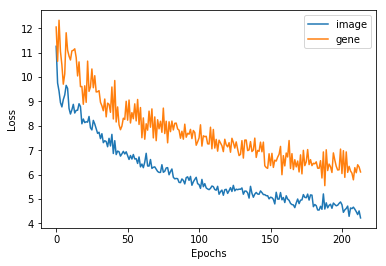

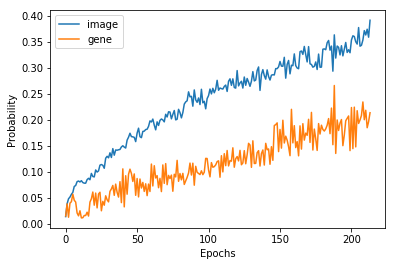

In [15]:
plt.plot(np.arange(len(hist['image_loss'])), hist['image_loss'])
plt.plot(np.arange(len(hist['gene_loss'])), hist['gene_loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["image", "gene"])
plt.show()
plt.plot(np.arange(len(hist['image_prob'])), hist['image_prob'])
plt.plot(np.arange(len(hist['gene_prob'])), hist['gene_prob'])
plt.xlabel("Epochs")
plt.ylabel("Probability")
plt.legend(["image", "gene"])
plt.show()

In [ ]:
torch.save(hist, os.path.join(model_dir, "hist.pt"))

__Continue to train from epoch 200__

In [29]:
hist = torch.load(os.path.join(model_dir, "hist.pt")
n_epoch = 200
for key in hist.keys():
    hist[key] = [hist[key][_] for _ in range(n_epoch)]

In [30]:
model_file = "./models/Dataset_MOB/epoch_200.pt"
if model_file is not None:
    print("=> loading checkpoint '{}'".format(model_file))
    checkpoint = torch.load(model_file, map_location=device)
    start_epoch = checkpoint['epoch'] + 1
    model.load_state_dict(checkpoint['model'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    contrast.load_state_dict(checkpoint['contrast'])
    del checkpoint

# print(list(model.parameters()))

#### Continue to train with ? fixing imagenet

save_freq = 100
best_metric = float('inf')
best_epoch = -1
optimizer = torch.optim.SGD(model.parameters(),
                            lr=0.001,
                            momentum=momentum,
                            weight_decay=0.005)

# Fix?
for param in model.imagenet.parameters():
    param.requires_grad = False
for param in model.imagenet.fc.parameters():
    param.requires_grad = True

for epoch in range(start_epoch, 600):
    image_loss, image_prob, gene_loss, gene_prob = \
        train(epoch, train_loader, model, contrast, criterion_image, criterion_gene, optimizer, 
              gradient_clip=gradient_clip, print_freq=1, device=device)
    hist['image_loss'].append(image_loss)
    hist['image_prob'].append(image_prob)
    hist['gene_loss'].append(gene_loss)
    hist['gene_prob'].append(gene_prob)
    metric = image_loss + gene_loss
    # Save model
    if metric < best_metric:
        best_metric = metric
        best_epoch = epoch

        state = {
            'model': model.state_dict(),
            'contrast': contrast.state_dict(),
            'optimizer': optimizer.state_dict(),
            'epoch': epoch
        }
        torch.save(state, os.path.join(model_dir, "epoch_best.pt"))

    if epoch % save_freq == 0 and epoch != 0:
        print("Saving model...")
        state = { 'model': model.state_dict(),
                  'contrast': contrast.state_dict(),
                  'optimizer': optimizer.state_dict(),
                  'epoch': epoch}
        torch.save(state, os.path.join(model_dir, "epoch_{}.pt".format(epoch)))

torch.save(hist, os.path.join(model_dir, "hist.pt"))

=> loading checkpoint './models/IGCNet_02182020/epoch_200.pt'
Epoch: [201][1/54]	loss 14.642 (14.642)	image_p 0.115 (0.115)	gene_p 0.098 (0.098)
Epoch: [201][2/54]	loss 12.152 (13.397)	image_p 0.232 (0.174)	gene_p 0.084 (0.091)
Epoch: [201][3/54]	loss 12.317 (13.037)	image_p 0.197 (0.181)	gene_p 0.203 (0.128)
Epoch: [201][4/54]	loss 10.451 (12.391)	image_p 0.235 (0.195)	gene_p 0.192 (0.144)
Epoch: [201][5/54]	loss 11.372 (12.187)	image_p 0.238 (0.203)	gene_p 0.174 (0.150)
Epoch: [201][6/54]	loss 12.624 (12.260)	image_p 0.186 (0.201)	gene_p 0.158 (0.152)
Epoch: [201][7/54]	loss 12.304 (12.266)	image_p 0.255 (0.208)	gene_p 0.094 (0.143)
Epoch: [201][8/54]	loss 11.195 (12.132)	image_p 0.309 (0.221)	gene_p 0.108 (0.139)
Epoch: [201][9/54]	loss 11.970 (12.114)	image_p 0.308 (0.231)	gene_p 0.115 (0.136)
Epoch: [201][10/54]	loss 13.425 (12.245)	image_p 0.251 (0.233)	gene_p 0.108 (0.133)
Epoch: [201][11/54]	loss 12.673 (12.284)	image_p 0.184 (0.228)	gene_p 0.167 (0.136)
Epoch: [201][12/54]	los

In [31]:
print(contrast.memory_image)

tensor([[-0.1553, -0.1234,  0.0939,  ..., -0.0146,  0.0813,  0.0900],
        [-0.1144, -0.1707,  0.0899,  ..., -0.0607,  0.0982,  0.0294],
        [-0.1431, -0.1552,  0.0606,  ..., -0.0488,  0.1002,  0.0049],
        ...,
        [-0.1093, -0.1893,  0.0776,  ..., -0.0318,  0.0718,  0.0579],
        [-0.0137, -0.1576,  0.0877,  ..., -0.1255,  0.0811,  0.0508],
        [-0.0918, -0.1361,  0.0884,  ..., -0.0768,  0.1187,  0.0416]],
       device='cuda:1')


In [32]:
print(contrast.memory_gene)

tensor([[-0.1600, -0.0126,  0.0037,  ...,  0.0687,  0.0383,  0.0257],
        [-0.0855, -0.0145,  0.0283,  ...,  0.0179,  0.0497,  0.0416],
        [-0.1779, -0.0562, -0.0342,  ...,  0.0301,  0.0791, -0.0559],
        ...,
        [ 0.0093, -0.0371,  0.0187,  ..., -0.0694,  0.0310,  0.0574],
        [ 0.0787, -0.0188,  0.0127,  ..., -0.1426,  0.0251,  0.0049],
        [ 0.0049,  0.0818,  0.0340,  ..., -0.1097,  0.0805,  0.0360]],
       device='cuda:1')


In [33]:
print("Saving model epoch {}...".format(epoch))
state = { 'model': model.state_dict(),
          'contrast': contrast.state_dict(),
          'optimizer': optimizer.state_dict(),
          'epoch': epoch}
torch.save(state, "./models/Dataset_MOB/epoch_{}.pt".format(epoch))

Saving model epoch 599...


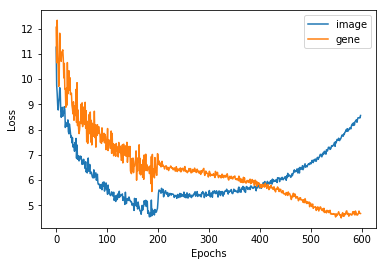

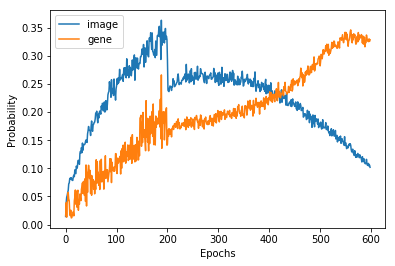

In [34]:
plt.plot(np.arange(len(hist['image_loss'])), hist['image_loss'])
plt.plot(np.arange(len(hist['gene_loss'])), hist['gene_loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["image", "gene"])
plt.show()
plt.plot(np.arange(len(hist['image_prob'])), hist['image_prob'])
plt.plot(np.arange(len(hist['gene_prob'])), hist['gene_prob'])
plt.xlabel("Epochs")
plt.ylabel("Probability")
plt.legend(["image", "gene"])
plt.show()

__continue to train from epoch 599__

In [38]:
model_file = "./models/Dataset_MOB/epoch_599.pt"
if model_file is not None:
    print("=> loading checkpoint '{}'".format(model_file))
    checkpoint = torch.load(model_file, map_location=device)
    start_epoch = checkpoint['epoch'] + 1
    model.load_state_dict(checkpoint['model'])
    optimizer.load_state_dict(checkpoint['optimizer'])
    contrast.load_state_dict(checkpoint['contrast'])
    del checkpoint

# print(list(model.parameters()))

#### Continue to train with ? fixing imagenet

save_freq = 100
best_metric = float('inf')
best_epoch = -1
optimizer = torch.optim.SGD(model.parameters(),
                            lr=0.001,
                            momentum=momentum,
                            weight_decay=0.005)

# Fix?
for param in model.imagenet.parameters():
    param.requires_grad = True
for param in model.imagenet.fc.parameters():
    param.requires_grad = True

for epoch in range(start_epoch, 2000):
    image_loss, image_prob, gene_loss, gene_prob = \
        train(epoch, train_loader, model, contrast, criterion_image, criterion_gene, optimizer, 
              gradient_clip=gradient_clip, print_freq=10, device=device)
    hist['image_loss'].append(image_loss)
    hist['image_prob'].append(image_prob)
    hist['gene_loss'].append(gene_loss)
    hist['gene_prob'].append(gene_prob)
    metric = image_loss + gene_loss
    # Save model
    if metric < best_metric:
        best_metric = metric
        best_epoch = epoch

        state = {
            'model': model.state_dict(),
            'contrast': contrast.state_dict(),
            'optimizer': optimizer.state_dict(),
            'epoch': epoch
        }
        torch.save(state, os.path.join(model_dir, "epoch_best.pt"))

    if epoch % save_freq == 0 and epoch != 0:
        print("Saving model...")
        state = { 'model': model.state_dict(),
                  'contrast': contrast.state_dict(),
                  'optimizer': optimizer.state_dict(),
                  'epoch': epoch}
        torch.save(state, os.path.join(model_dir, "epoch_{}.pt".format(epoch)))

torch.save(hist, os.path.join(model_dir, "hist.pt"))

print("Saving model epoch {}...".format(epoch))
state = { 'model': model.state_dict(),
          'contrast': contrast.state_dict(),
          'optimizer': optimizer.state_dict(),
          'epoch': epoch}
torch.save(state, "./models/Dataset_MOB/epoch_{}.pt".format(epoch))


=> loading checkpoint './models/IGCNet_02182020/epoch_599.pt'
Epoch: [600][10/54]	loss 13.050 (12.920)	image_p 0.133 (0.118)	gene_p 0.409 (0.317)
Epoch: [600][20/54]	loss 11.994 (12.725)	image_p 0.153 (0.137)	gene_p 0.327 (0.303)
Epoch: [600][30/54]	loss 11.563 (12.376)	image_p 0.189 (0.155)	gene_p 0.241 (0.296)
Epoch: [600][40/54]	loss 11.090 (12.124)	image_p 0.183 (0.167)	gene_p 0.320 (0.284)
Epoch: [600][50/54]	loss 9.504 (11.913)	image_p 0.357 (0.182)	gene_p 0.323 (0.268)
Saving model...
Epoch: [601][10/54]	loss 10.513 (9.545)	image_p 0.303 (0.298)	gene_p 0.291 (0.364)
Epoch: [601][20/54]	loss 9.182 (9.818)	image_p 0.309 (0.274)	gene_p 0.419 (0.347)
Epoch: [601][30/54]	loss 9.241 (9.878)	image_p 0.326 (0.280)	gene_p 0.253 (0.330)
Epoch: [601][40/54]	loss 11.534 (9.822)	image_p 0.207 (0.287)	gene_p 0.300 (0.322)
Epoch: [601][50/54]	loss 11.795 (9.640)	image_p 0.256 (0.307)	gene_p 0.229 (0.320)
Epoch: [602][10/54]	loss 8.224 (7.547)	image_p 0.403 (0.388)	gene_p 0.425 (0.500)
Epoch: [

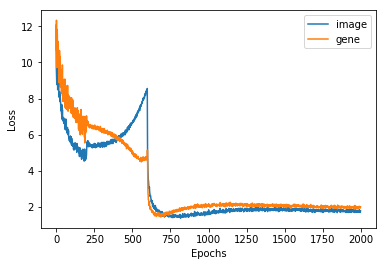

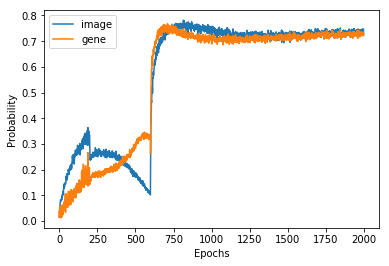

In [39]:
plt.plot(np.arange(len(hist['image_loss'])), hist['image_loss'])
plt.plot(np.arange(len(hist['gene_loss'])), hist['gene_loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend(["image", "gene"])
plt.show()
plt.plot(np.arange(len(hist['image_prob'])), hist['image_prob'])
plt.plot(np.arange(len(hist['gene_prob'])), hist['gene_prob'])
plt.xlabel("Epochs")
plt.ylabel("Probability")
plt.legend(["image", "gene"])
plt.show()